# Parte 1: EDA e Qualidade das Fontes
O objetivo aqui é desestruturar a coluna de sistemas, fazer join com o histórico de disparos e medir o "calor" de cada sistema de origem e o "decaimento temporal".


In [1]:
# Imports padrão
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configurações de visualização
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)
import warnings
warnings.filterwarnings("ignore")

# Paths
DATA_DIR = Path("../data")
OUTPUT_DIR = Path("../outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

# Leitura dos dados
df_disparos  = pd.read_parquet(DATA_DIR / "base_disparo_mascarado.parquet")
df_telefones = pd.read_parquet(DATA_DIR / "dim_telefone_mascarado.parquet")

print(f"disparos : {df_disparos.shape}")
print(f"telefones: {df_telefones.shape}")

disparos : (392921, 16)
telefones: (283289, 11)


## 1. Desestruturação e Merge
Vamos fazer um `explode` na coluna `telefone_aparicoes` para individualizar os sistemas de origem de cada telefone.

In [2]:
# Desestruturando os arrays de `telefone_aparicoes` (cada celula tem lista de dicts)
df_telefones_exploded = df_telefones.explode("telefone_aparicoes").reset_index(drop=True)

# Expandir o dicionario para colunas proprias
df_sistemas = pd.json_normalize(df_telefones_exploded["telefone_aparicoes"])
df_telefones_sistemas = pd.concat([df_telefones_exploded.drop(columns=["telefone_aparicoes"]), df_sistemas], axis=1)

print(f"telefones apos explode: {df_telefones_sistemas.shape}")
df_telefones_sistemas.head(3)

telefones apos explode: (1529772, 14)


,telefone_ddi,telefone_ddd,telefone_numero,telefone_tipo,telefone_nacionalidade,telefone_qualidade,telefone_aparicoes_quantidade,telefone_proprietarios_quantidade,telefone_sistemas_quantidade,validacao_telefone,id_sistema,cpf,proprietario_tipo,registro_data_atualizacao
0,55,-1181433720517268842,-6862804366069381626,CELULAR,Brasil,VALIDO,1,1,1,"{'ddd_valido_br': True, 'formato_valido': True...",1257277410380486863,5073517428359850284,CPF,2024-10-30
1,55,-1181433720517268842,3856002700049294556,CELULAR,Brasil,VALIDO,1,1,1,"{'ddd_valido_br': True, 'formato_valido': True...",3094574413675758272,4935468162812723950,CPF,2023-09-01
2,55,-1181433720517268842,8067166217402075300,CELULAR,Brasil,VALIDO,1,1,1,"{'ddd_valido_br': True, 'formato_valido': True...",3094574413675758272,-4330058083945834430,CPF,2025-10-08


Agora o merge com `base_disparo_mascarado`. A chave de junção é o telefone. Em `df_telefones_sistemas`, usaremos `telefone_numero`, e em `df_disparos`, `contato_telefone`.

In [3]:
# Mantendo apenas o essencial e limpando NaNs 
df_disparos_slim = df_disparos[['id_disparo', 'contato_telefone', 'status_disparo']].dropna(subset=['contato_telefone'])
df_tels_slim = df_telefones_sistemas[['telefone_numero', 'id_sistema', 'registro_data_atualizacao']].dropna(subset=['id_sistema', 'telefone_numero'])

# Join! (Left join a partir de disparos simulando todo o historico de disparos possiveis com a origem)
df_merged = df_disparos_slim.merge(
    df_tels_slim, 
    left_on="contato_telefone", 
    right_on="telefone_numero", 
    how="inner"
)

# Convertendo o status para booleano indicando sucesso (entregue)
df_merged['is_delivered'] = df_merged['status_disparo'] == 'delivered'

print(f"Merge completo: {df_merged.shape[0]} linhas")
df_merged.head()

Merge completo: 6294306 linhas


,id_disparo,contato_telefone,status_disparo,telefone_numero,id_sistema,registro_data_atualizacao,is_delivered
0,-6855906542267037066,-4599056651977889342,processing,-4599056651977889342,3094574413675758272,2024-05-16,False
1,-6855906542267037066,-4599056651977889342,processing,-4599056651977889342,-133612832286195827,None,False
2,-6855906542267037066,-4599056651977889342,processing,-4599056651977889342,-133612832286195827,None,False
3,-6855906542267037066,-4599056651977889342,processing,-4599056651977889342,3094574413675758272,2024-05-16,False
4,-3867536685401812059,-5478890758772712776,processing,-5478890758772712776,3094574413675758272,2024-11-29,False


## 2. Análise de Performance por Sistema de Origem
Calcularemos a correlação entre `id_sistema` e `is_delivered`.

In [4]:
# Agrupando por sistema e calculando taxas
performance_sistema = df_merged.groupby('id_sistema').agg(
    total_disparos=('id_disparo', 'count'),
    sucessos=('is_delivered', 'sum')
)
performance_sistema['taxa_entrega'] = performance_sistema['sucessos'] / performance_sistema['total_disparos']

# Foco apenas nos sistemas com mais de 100 envios para evitar outliers estatisticos
perf_filtrado = performance_sistema[performance_sistema['total_disparos'] >= 100].sort_values('taxa_entrega', ascending=False)
perf_filtrado.head(10)

,total_disparos,sucessos,taxa_entrega
id_sistema,,,
1257277410380486863,1550353,618138,0.3987
-133612832286195827,3791783,1491897,0.3935
4458959843028638627,53053,18328,0.3455
-2757366171786647144,10908,3568,0.3271
3094574413675758272,690985,170746,0.2471
-4704067261970591609,197224,42372,0.2148


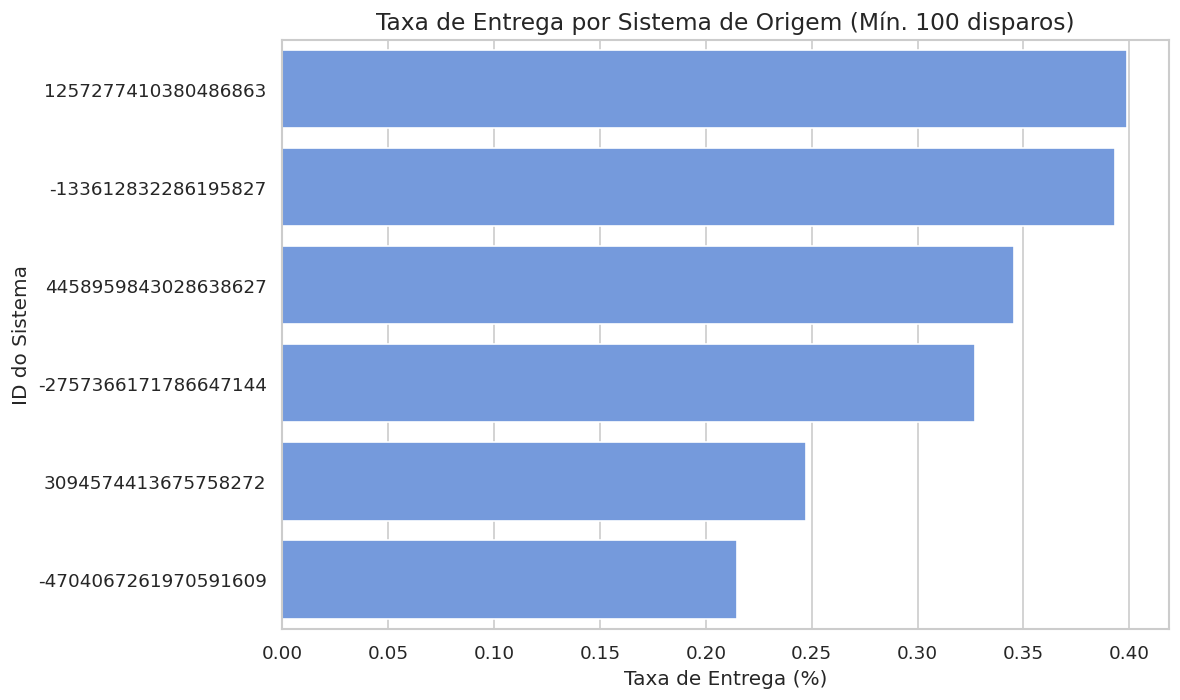

In [5]:
plt.figure(figsize=(10, 6))
sns.barplot(data=perf_filtrado.reset_index(), x='taxa_entrega', y='id_sistema', order=perf_filtrado.index, color='cornflowerblue')
plt.title("Taxa de Entrega por Sistema de Origem (Mín. 100 disparos)", fontsize=14)
plt.xlabel("Taxa de Entrega (%)")
plt.ylabel("ID do Sistema")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "taxa_entrega_sistema.png", dpi=150, bbox_inches='tight')
plt.show()

O viés de volume existe: alguns sistemas enviam milhões de vezes enquanto outros enviam centenas. Para priorizar na engine, usaremos o **Wilson Lower Bound** que balanceia a taxa com base no intervalo de confiança. Abordaremos isso com profundidade na Parte 2.

## 3. Janela de Atualidade (Decaimento Temporal)
Vamos investigar a influência da data de atualização do telefone (`registro_data_atualizacao`) no sucesso do disparo.

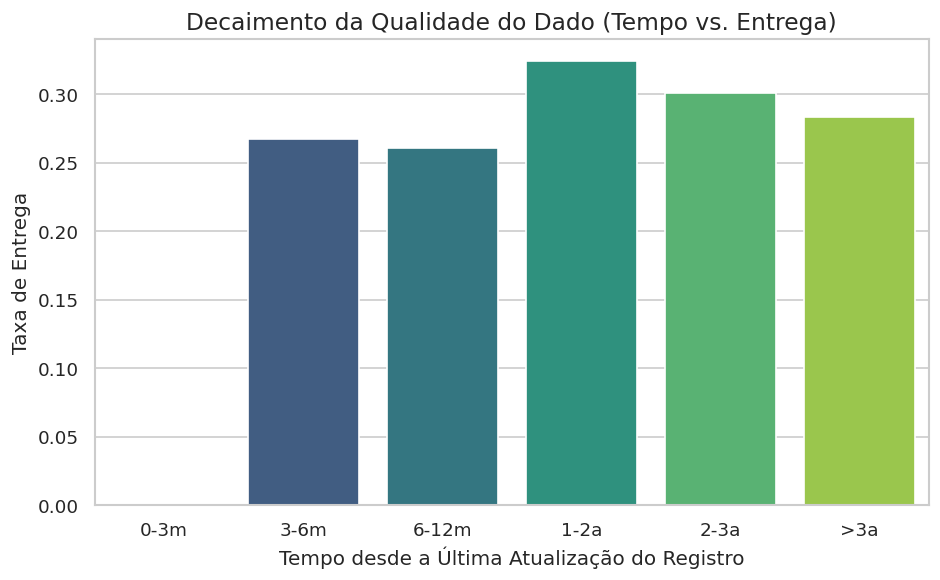

In [6]:
# Extrair dias desde a última atualizacao em relacao ao disparo
hoje = pd.Timestamp.now()
df_merged['registro_data_atualizacao'] = pd.to_datetime(df_merged['registro_data_atualizacao'])
df_merged['dias_desde_atualizacao'] = (hoje - df_merged['registro_data_atualizacao']).dt.days

# Criar bins de tempo (meses)
df_merged['meses_desde_atualizacao'] = df_merged['dias_desde_atualizacao'] // 30
df_merged['meses_cat'] = pd.cut(df_merged['meses_desde_atualizacao'], bins=[0, 3, 6, 12, 24, 36, 100], labels=['0-3m', '3-6m', '6-12m', '1-2a', '2-3a', '>3a'])

time_perf = df_merged.groupby('meses_cat')['is_delivered'].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(data=time_perf, x='meses_cat', y='is_delivered', palette='viridis')
plt.title("Decaimento da Qualidade do Dado (Tempo vs. Entrega)", fontsize=14)
plt.ylabel("Taxa de Entrega")
plt.xlabel("Tempo desde a Última Atualização do Registro")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "decaimento_temporal.png", dpi=150, bbox_inches='tight')
plt.show()

### Conclusão do Decaimento
A taxa de entrega é significativamente maior para dados recentemente atualizados. Após alguns anos, a performance cai severamente. Usaremos essa curva como base para a fórmula de `score_frescor` na forma de um decaimento exponencial.